In [520]:
import random # Para gerar números aleatórios (se necessário)
import matplotlib.pyplot as plt # Base para os gráficos
import seaborn as sns # Para gráficos estatísticos bonitos
import pandas as pd # Para manipulação de tabelas de dados
import numpy as np # Para cálculos estatísticos eficientes

In [521]:
class Monitor_temperature:
    def __init__(self, min_temperature, max_temperature):
        # Método construtor: define os limites de segurança e inicia a lista
        self.min_temp = min_temperature
        self.max_temp = max_temperature
        self.leituras = []

    def add_temperature(self, numbers_of_temperatures, min_temp_to_register, max_temp_to_register, is_random_temp=True):
        '''
        Função para adicionar temperaturas simuladas.
        - is_random_temp=True: Gera valores aleatórios.
        - is_random_temp=False: Gera um padrão de aquecimento linear e resfriamento (Dente de Serra).
        '''
        print(f"--- Gerando {numbers_of_temperatures} leituras ---")

        # Inicializa a temperatura base
        temperature = min_temp_to_register

        for i in range(numbers_of_temperatures):
            if is_random_temp:
                # Geração totalmente aleatória
                temperature = round(random.uniform(min_temp_to_register, max_temp_to_register), 2)
            else:
                # Simulação de aquecimento progressivo
                temperature += 1

                # Se passar do limite máximo da simulação, ativa "resfriamento"
                if temperature > max_temp_to_register:
                    print(f"❄️ Resfriamento de emergência ativado na leitura {i}!")
                    temperature = temperature / 2 # temperatura cai pela metade

            # Garante arredondamento e adiciona à lista
            temperature = round(temperature, 2)
            print(f"Leitura {i+1}: {temperature}°C")
            self.leituras.append(temperature)

        print("Leituras concluídas.")

    def calculate_statistic(self):
        ''' Calcula a temperatura máxima, média e mínima '''
        # Se não houver leituras, retorna a mensagem
        if not self.leituras:
            return "Nenhuma leitura registrada."

        dados = np.array(self.leituras) # Conversão para NumPy para eficiência

        statistic = {
            'max' : dados.max(),
            'mean' : round(dados.mean(), 2),
            'min' : dados.min()
        }
        return statistic

    def check_temperature(self):
        ''' Verifica se as leituras estão dentro dos limites de segurança da classe '''
        irregular_temperature = False

        print("\n--- Verificando Segurança ---")
        for index, temperature in enumerate(self.leituras):
            if temperature < self.min_temp or temperature > self.max_temp:
                print(f"⚠️ ALERTA na leitura {index+1}: {temperature:.2f}°C (Fora de {self.min_temp}-{self.max_temp})")
                irregular_temperature = True

        if not irregular_temperature:
            print("✅ Tudo certo! Temperaturas dentro dos padrões estabelecidos. ✅")

    def plot_history(self):
        ''' Gera um gráfico visual das temperaturas com linhas de limite '''
        if not self.leituras:
            print("Sem dados para plotar.")
            return

        # Criação do DataFrame para o Seaborn
        df = pd.DataFrame({
            'Tempo': range(len(self.leituras)),
            'Temperatura': self.leituras
        })

        # Configuração do Gráfico
        plt.figure(figsize=(15, 6)) # Tamanho do gráfico, largura e altura

        # Desenha a linha das leituras
        sns.lineplot(data=df, x='Tempo', y='Temperatura', marker='o', label='Sensor 1')

        # Linhas de Limite (Visualização dos alertas)
        plt.axhline(y=self.min_temp, color='b', linestyle='--', label='Mínimo Seguro')
        plt.axhline(y=self.max_temp, color='r', linestyle='--', label='Máximo Seguro')

        plt.title('Monitoramento de Temperatura em Tempo Real')
        plt.ylabel('Temperatura (°C)')
        plt.xlabel('Sequência de Leitura')
        plt.legend()
        plt.grid(True)
        plt.show()

## Execução do programa

In [522]:
# Instancia a classe (Limites seguros: 20°C a 80°C)
monitor = Monitor_temperature(20, 80)

In [523]:
# Gera dados (Simulando aquecimento até 81°C para testar o resfriamento e alertas)
# is_random_temp=False para usar o aquecimento de "dente de serra", caso seja True, irá registrar dados aleatórios
monitor.add_temperature(150, 19, 81, is_random_temp=False)

--- Gerando 150 leituras ---
Leitura 1: 20°C
Leitura 2: 21°C
Leitura 3: 22°C
Leitura 4: 23°C
Leitura 5: 24°C
Leitura 6: 25°C
Leitura 7: 26°C
Leitura 8: 27°C
Leitura 9: 28°C
Leitura 10: 29°C
Leitura 11: 30°C
Leitura 12: 31°C
Leitura 13: 32°C
Leitura 14: 33°C
Leitura 15: 34°C
Leitura 16: 35°C
Leitura 17: 36°C
Leitura 18: 37°C
Leitura 19: 38°C
Leitura 20: 39°C
Leitura 21: 40°C
Leitura 22: 41°C
Leitura 23: 42°C
Leitura 24: 43°C
Leitura 25: 44°C
Leitura 26: 45°C
Leitura 27: 46°C
Leitura 28: 47°C
Leitura 29: 48°C
Leitura 30: 49°C
Leitura 31: 50°C
Leitura 32: 51°C
Leitura 33: 52°C
Leitura 34: 53°C
Leitura 35: 54°C
Leitura 36: 55°C
Leitura 37: 56°C
Leitura 38: 57°C
Leitura 39: 58°C
Leitura 40: 59°C
Leitura 41: 60°C
Leitura 42: 61°C
Leitura 43: 62°C
Leitura 44: 63°C
Leitura 45: 64°C
Leitura 46: 65°C
Leitura 47: 66°C
Leitura 48: 67°C
Leitura 49: 68°C
Leitura 50: 69°C
Leitura 51: 70°C
Leitura 52: 71°C
Leitura 53: 72°C
Leitura 54: 73°C
Leitura 55: 74°C
Leitura 56: 75°C
Leitura 57: 76°C
Leitura 58:

In [524]:
# Calcula e exibe estatísticas
statistic = monitor.calculate_statistic()
print("\n📊 Estatísticas Gerais:")
print(f"Máxima: {statistic['max']:.2f}°C")
print(f"Média:  {statistic['mean']:.2f}°C")
print(f"Mínima: {statistic['min']:.2f}°C")


📊 Estatísticas Gerais:
Máxima: 81.00°C
Média:  55.96°C
Mínima: 20.00°C


In [525]:
# Verifica alertas de segurança
monitor.check_temperature()


--- Verificando Segurança ---
⚠️ ALERTA na leitura 62: 81.00°C (Fora de 20-80)
⚠️ ALERTA na leitura 103: 81.00°C (Fora de 20-80)
⚠️ ALERTA na leitura 144: 81.00°C (Fora de 20-80)


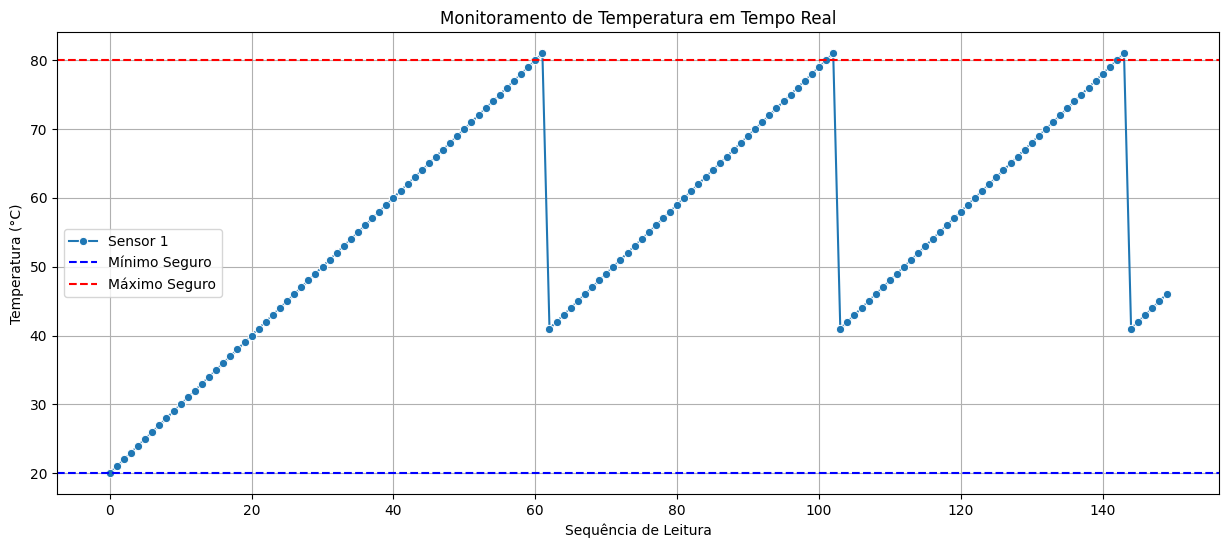

In [526]:
# Gera o gráfico
monitor.plot_history()